# Exercice 3.1 : Détection d'anomalies manuelle avec Isolation Forest
Dans cet atelier, nous entraînons une forêt d'isolation et ajustons manuellement le seuil d'alerte pour comprendre la gestion des alertes en SOC.

#### 1. Chargement et normalisation rapide

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler

data = pd.read_csv('data/UNSW_NB15_training-set.csv')
features = data.copy()
for col in features.select_dtypes(include=['object']).columns:
    features[col] = LabelEncoder().fit_transform(features[col].astype(str))
X_scaled = RobustScaler().fit_transform(features)
print("Données prêtes :", X_scaled.shape)

Données prêtes : (82332, 45)


#### 2. Isolation Forest et scores continus

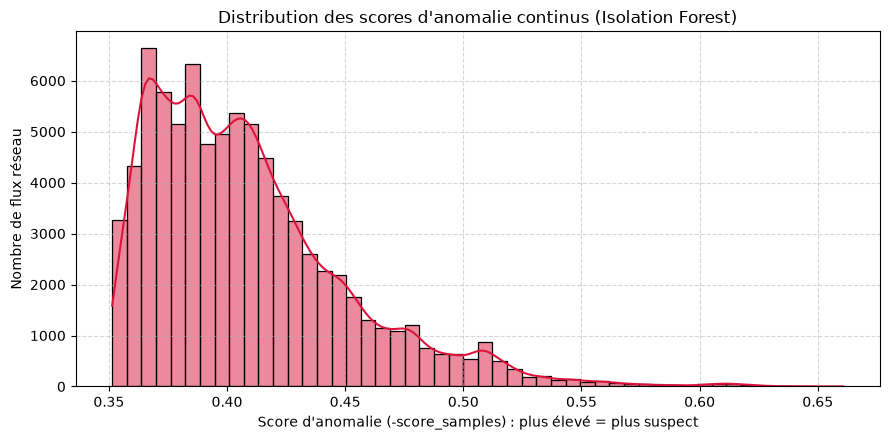

Score min : 0.351 | Médian : 0.401 | Max : 0.661


In [4]:
from sklearn.ensemble import IsolationForest
from helper import plot_anomaly_histogram
import numpy as np

# Entraînement et calcul des scores d'anomalie
iso = IsolationForest(n_estimators=100, random_state=42, n_jobs=-1).fit(X_scaled)
scores = -iso.score_samples(X_scaled)

plot_anomaly_histogram(scores)
print(f"Score min : {scores.min():.3f} | Médian : {np.median(scores):.3f} | Max : {scores.max():.3f}")

#### 3. Réglage manuel du seuil SOC : Alerter sur 1% vs 5% vs 10%

In [8]:
scores

array([0.37051292, 0.42023229, 0.39948793, ..., 0.50687014, 0.51016131,
       0.36723539])

In [7]:
from helper import plot_flagged_scatter

# <-- CHANGEZ LE SEUIL PERCENTILE (ex: 99 pour 1% d'alertes, 95 pour 5%, 90 pour 10%) !
seuil_pct = 95

threshold = np.percentile(scores, seuil_pct)
is_flagged = (scores >= threshold).astype(int)
print(f"Seuil fixé à {threshold:.3f} -> {is_flagged.sum()} flux signalés en alerte.")

Seuil fixé à 0.495 -> 4120 flux signalés en alerte.


#### 4. Profilage des alertes : Qu'est-ce qui rend ces flux anormaux ?

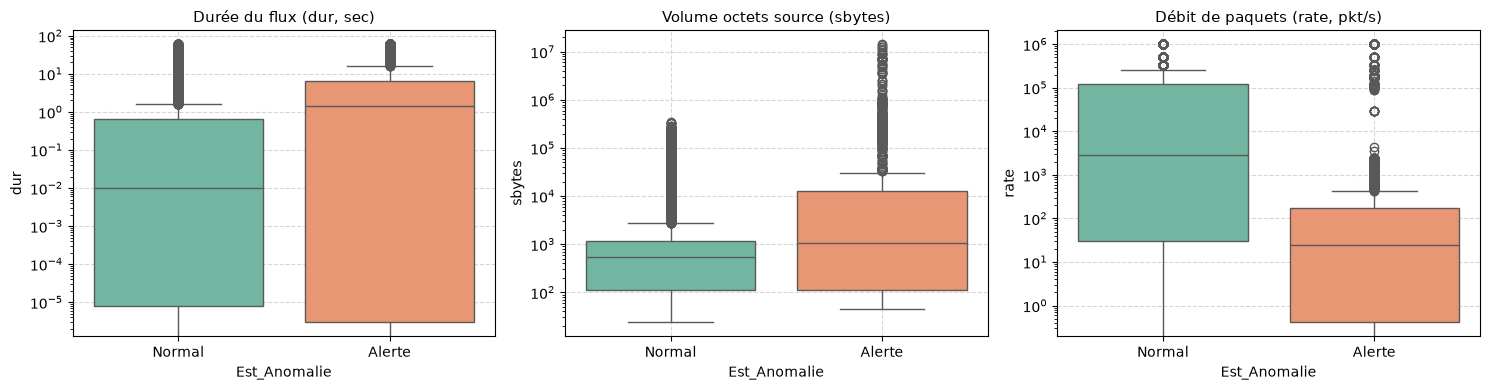

In [6]:
from helper import plot_alert_boxplots

data_eval = data.copy()
data_eval['Est_Anomalie'] = is_flagged
plot_alert_boxplots(data_eval, flag_col='Est_Anomalie', cols=['dur', 'sbytes', 'rate'])

# À faire :
1. Jouer avec les seuils
2. En tant que membre de l'équipe sécurité, c'est ici où vous pouvez le plus aider avec votre compréhension du métier et des données réels de vos outils. Discuter avec l'équipe IA pour mieux gérer la donnée.